In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import itertools

from snn import Network, NodeGroup, EdgeGroup, NodePort, NodeList
from snn.model import IN, LIF, PSP

In [2]:
class Input(Network):
    def __init__(self, spike_times):
        super().__init__()
        # inputs to snn is generally tricky
        # here we use lists of spike times
        self.spike_times = spike_times # n x t

    def build(self):
        self.spikegen = NodeGroup(IN(), len(self.spike_times))

        return

In [3]:
# Example network attempting to be more general
class MultiAnd(Network):
    def __init__(self):
        super().__init__()
        self.input = [NodePort()] # non-initialized list of input ports

    def build(self):
        len_inputs = len(self.input)
        num_inputs = self.input[0].size
        
        # Nodes can be procedurally generated
        self.output = NodeGroup(LIF(threshold=1.0*len_inputs-0.5), num_inputs)

        # Edges can also be procedurally generated
        self.i__o = [] # non-initialized list for edge groups (can be empty list)
        for i in range(len_inputs):
            self.i__o.append(EdgeGroup(self.input[0], self.output, PSP(),
                                       edges=[(j,j) for j in range(num_inputs)]))
        return

In [4]:
# Example network how you might normally implement it instead
class MultiOr(Network):
    def __init__(self, num_inputs=None):
        super().__init__()
        self.input = [NodePort(num_inputs),
                      NodePort(num_inputs)]

    def build(self):
        num_inputs = self.input[0].size
        self.output = NodeGroup(LIF(threshold=0.5), num_inputs)

        # Can also connect with unnamed edge groups
        self.connect(self.input[0], self.output, PSP(weight=0.75),
                     edges=[(i,i) for i in range(num_inputs)])
        self.i1__o = EdgeGroup(self.input[1], self.output, PSP(weight=0.75),
                             edges=[(i,i) for i in range(num_inputs)])
        return

In [5]:
# Inputs from dense vectors to sparse times
def dense_to_sparse(in_spikes):
    in_n , in_t = np.where(np.asarray(in_spikes) == 1)
    in_times = [[] for _ in range(len(in_spikes))]
    for n, t in zip(in_n, in_t):
        in_times[n].append(t)
    return in_times

# Dense vector (n x t) = (5 x 3)
ina_spikes = [[1, 1, 0],
              [0, 1, 1],
              [1, 1, 0],
              [0, 1, 1],
              [1, 1, 1]]
ino_spikes = [[1, 0, 1],
              [1, 1, 1],
              [0, 0, 1],
              [0, 0, 0],
              [1, 1, 0]]

# Dense to sparse
ina_times = dense_to_sparse(ina_spikes)
ino_times = dense_to_sparse(ino_spikes)

In [6]:
net = Network()

net.i = [Input(spike_times=ina_times),
         Input(spike_times=ino_times)]
net.a = MultiAnd()
net.o = MultiOr()

# We can add ports to the initialized network, but before the network is built,
# we need to use the 'access' method because it is currently a temporary path
net.access('a').input.append(NodePort()) # leaving port size uinitialized

# A helper method for manually breaking dependency cycles (try commenting out)
net.set_portsize(net.a.input[1], len(ina_times))
# You can also just use the access method again here
# net.access('a').input[1].set_size(len(ina_times))

# Connect as usual
net.connect(net.i[0].spikegen, net.a.input[0])
net.connect(net.i[1].spikegen, net.o.input[0])
net.connect(net.a.output, net.o.input[1])
net.connect(net.o.output, net.a.input[1])

info: adding list of networks i
info: adding network a
info: adding network o


In [7]:
net.build()

info: building network i[0]
info: building network i[1]
info: linking port a.input[0]
info: linking port o.input[0]
info: waiting on source a.output
info: waiting on source o.output
info: resolving dependency for a.input
info: building network a
info: adding empty list a.i__o
info: linking port o.input[1]
info: waiting on source o.output
info: resolving dependency for o.input
info: building network o
info: adding unnamed edgegroup
info: linking port a.input[1]
info: flattening network topology


In [8]:
print(net)

(node) i[0].spikegen
(node) i[1].spikegen
(port) a.input[0] <- (node) i[0].spikegen
(port) a.input[1] <- (node) o.output
(node) a.output
(edge) a.i__o[0]: (port) a.input[0] <- (node) i[0].spikegen -> (node) a.output
(edge) a.i__o[1]: (port) a.input[0] <- (node) i[0].spikegen -> (node) a.output
(edge) o.edgegroups[0]: (port) o.input[0] <- (node) i[1].spikegen -> (node) o.output
(port) o.input[0] <- (node) i[1].spikegen
(port) o.input[1] <- (node) a.output
(node) o.output
(edge) o.i1__o: (port) o.input[1] <- (node) a.output -> (node) o.output


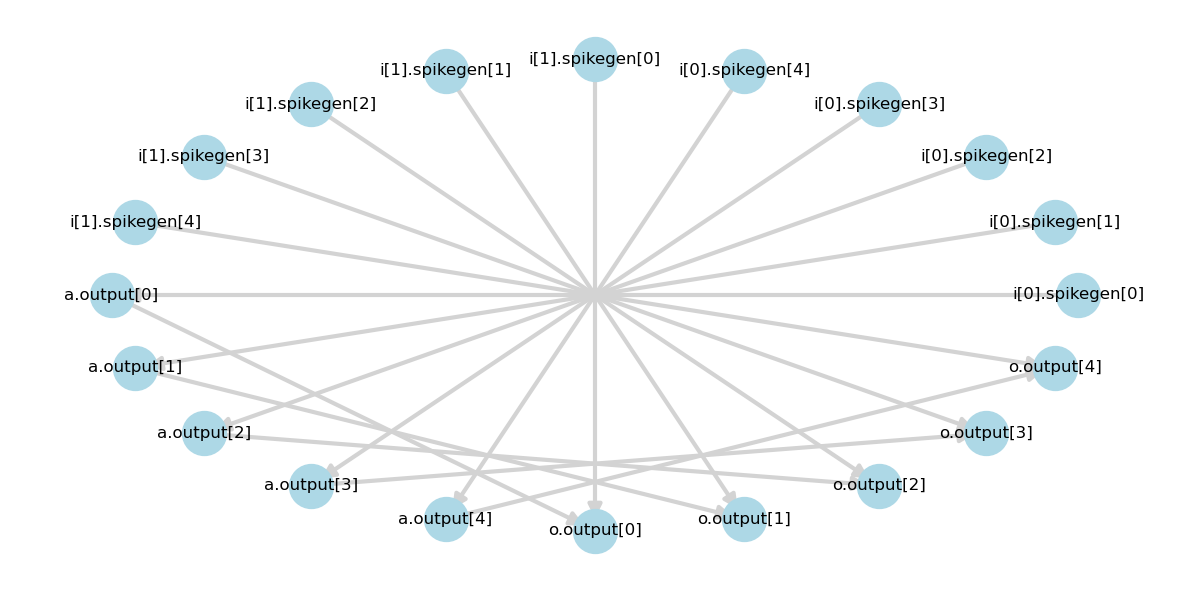

In [9]:
# Visualize the networkx graph
plt.figure(figsize=(12, 6))
pos = nx.circular_layout(net._graph)
nx.draw_networkx_nodes(net._graph, pos, node_size=1000, node_color='lightblue')
nx.draw_networkx_edges(net._graph, pos, edge_color='lightgray', width=3, arrowsize=20)
nx.draw_networkx_labels(net._graph, pos, font_size=12, font_color='black')
plt.axis('off')
plt.tight_layout()

In [10]:
net._topology

namespace(_network=<snn.network.Network at 0x1108a0090>,
          edgegroups=[],
          i=[namespace(_network=<__main__.Input at 0x1108a0190>,
                       edgegroups=[],
                       spikegen=[<snn.core.Node at 0x110501a40>,
                                 <snn.core.Node at 0x1108a1180>]),
             namespace(_network=<__main__.Input at 0x1108a0550>,
                       edgegroups=[],
                       spikegen=[<snn.core.Node at 0x11054a840>,
                                 <snn.core.Node at 0x1108a1300>])],
          a=namespace(_network=<__main__.MultiAnd at 0x1108a04d0>,
                      edgegroups=[],
                      input=[[<snn.core.Link at 0x110876590>,
                      output=[<snn.core.Node at 0x1105eab00>,
                      i__o=[[<snn.core.Edge at 0x1107eb290>,
                             <snn.core.Edge at 0x1108a4090>]]),
          o=namespace(_network=<__main__.MultiOr at 0x1108a0a50>,
                      edgegr